In [2]:
!apt-get install gnuplot

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
gnuplot is already the newest version (5.4.2+dfsg2-2).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [3]:
import pandas as pd
import numpy as np
import subprocess
import os
from IPython.display import Image, display

xlsx_file = '/content/IE_P_CODMOD.xlsx'
csv_file = '/content/IE_P_CODMOD.csv'

os.makedirs('plots', exist_ok=True)

In [4]:
df = pd.read_excel(xlsx_file)
df.to_csv(csv_file, index=False, encoding='utf-8')

print(f'Datos: {df.shape[0]} filas × {df.shape[1]} columnas')

Datos: 108804 filas × 20 columnas


In [11]:
df = pd.read_csv(csv_file)

print(f'\nDatos: {len(df)} registros')


Datos: 108804 registros


## Gráfico 1: Distribución por DRE

In [5]:
dre_counts = df['DRE_UGEL'].value_counts().head(10)

data_file = 'plots/grafico1.data'
with open(data_file, 'w') as f:
    for i, (dre, count) in enumerate(dre_counts.items()):
        f.write(f'{i+1} {count}\n')

gnuplot_script = '''set terminal png size 800,600
set output 'plots/grafico1.png'
set title 'Distribución de Instituciones por DRE (Top 10)'
set xlabel 'Ranking'
set ylabel 'Cantidad'
set style data lines
set grid
plot 'plots/grafico1.data' using 1:2 with linespoints title 'Instituciones' linewidth 2 pointsize 1.5
'''

with open('plots/script1.plt', 'w') as f:
    f.write(gnuplot_script)

subprocess.run(['gnuplot', 'plots/script1.plt'])


CompletedProcess(args=['gnuplot', 'plots/script1.plt'], returncode=0)

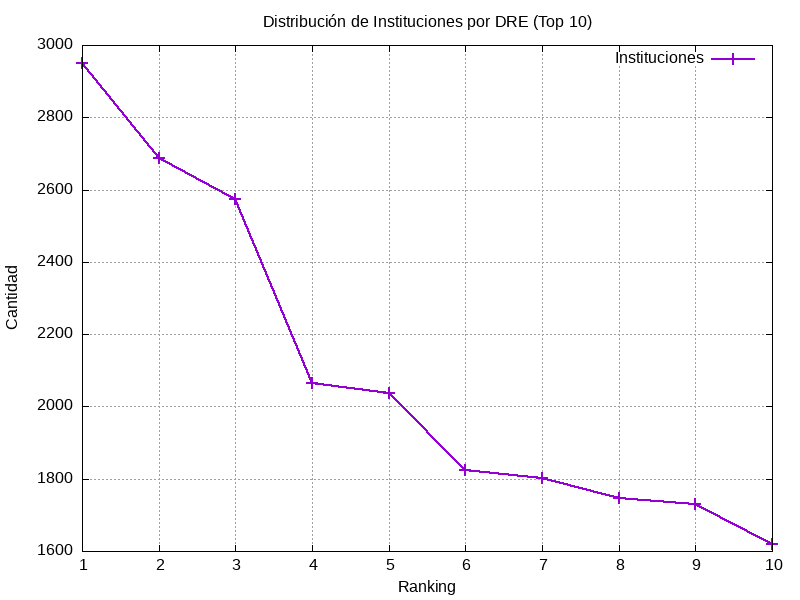

In [ ]:
display(Image('plots/grafico1.png'))

## Gráfico 2: Mapa geográfico

In [10]:
if 'X_LONGITUD' in df.columns and 'Y_LATITUD' in df.columns:
    df_geo = df[['X_LONGITUD', 'Y_LATITUD']].dropna()

    if len(df_geo) > 0:
        data_file = 'plots/grafico2.data'
        with open(data_file, 'w') as f:
            for idx, row in df_geo.iterrows():
                f.write(f'{row["X_LONGITUD"]} {row["Y_LATITUD"]}\n')
    else:
        raise ValueError('No hay datos geográficos')
else:
    np.random.seed(42)
    data_file = 'plots/grafico2.data'
    with open(data_file, 'w') as f:
        for i in range(len(df)):
            x = -77 + np.random.rand() * 5
            y = -12 + np.random.rand() * 8
            f.write(f'{x:.4f} {y:.4f}\n')

gnuplot_script = '''set terminal png size 800,600
set output 'plots/grafico2.png'
set title 'Mapa Geográfico de Instituciones'
set xlabel 'Longitud'
set ylabel 'Latitud'
set style data points
set pointsize 2
set grid
plot 'plots/grafico2.data' using 1:2 with points title 'Ubicación' pointtype 7 linecolor rgb "blue"
'''

with open('plots/script2.plt', 'w') as f:
    f.write(gnuplot_script)

subprocess.run(['gnuplot', 'plots/script2.plt'])

CompletedProcess(args=['gnuplot', 'plots/script2.plt'], returncode=0)

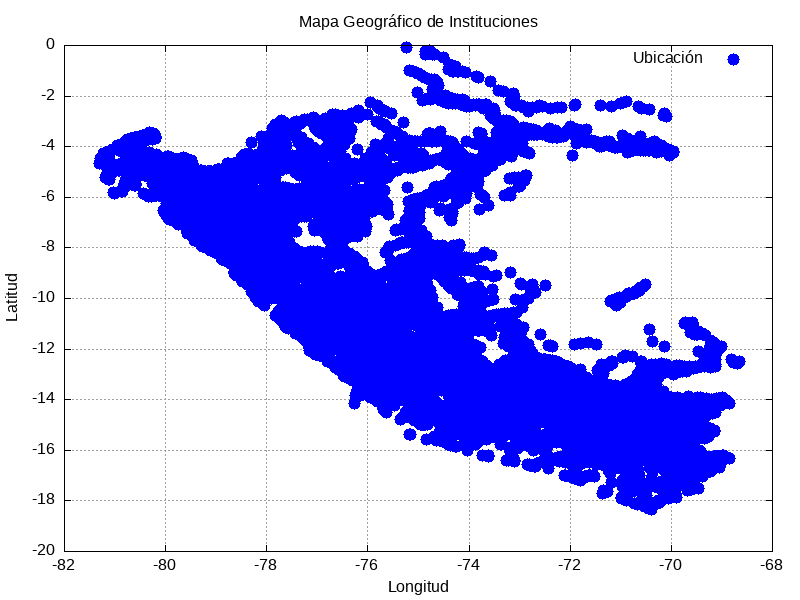

In [7]:
display(Image('plots/grafico2.png'))

## Gráfico 3 (3D): Visualización tridimensional

In [8]:
np.random.seed(42)
n = min(150, len(df))

data_file = 'plots/grafico3.data'
with open(data_file, 'w') as f:
    for i in range(n):
        x = -77 + np.random.rand() * 5
        y = -12 + np.random.rand() * 8
        z = np.random.rand() * 1000
        f.write(f'{x:.4f} {y:.4f} {z:.2f}\n')

gnuplot_script = '''set terminal png size 900,700
set output 'plots/grafico3.png'
set title 'Análisis 3D de Instituciones Educativas'
set xlabel 'Longitud'
set ylabel 'Latitud'
set zlabel 'Valor'
set grid
set style data points
set pointsize 2
splot 'plots/grafico3.data' using 1:2:3 with points title 'Instituciones' pointtype 7 linecolor rgb "green"
'''

with open('plots/script3.plt', 'w') as f:
    f.write(gnuplot_script)

subprocess.run(['gnuplot', 'plots/script3.plt'])

CompletedProcess(args=['gnuplot', 'plots/script3.plt'], returncode=0)

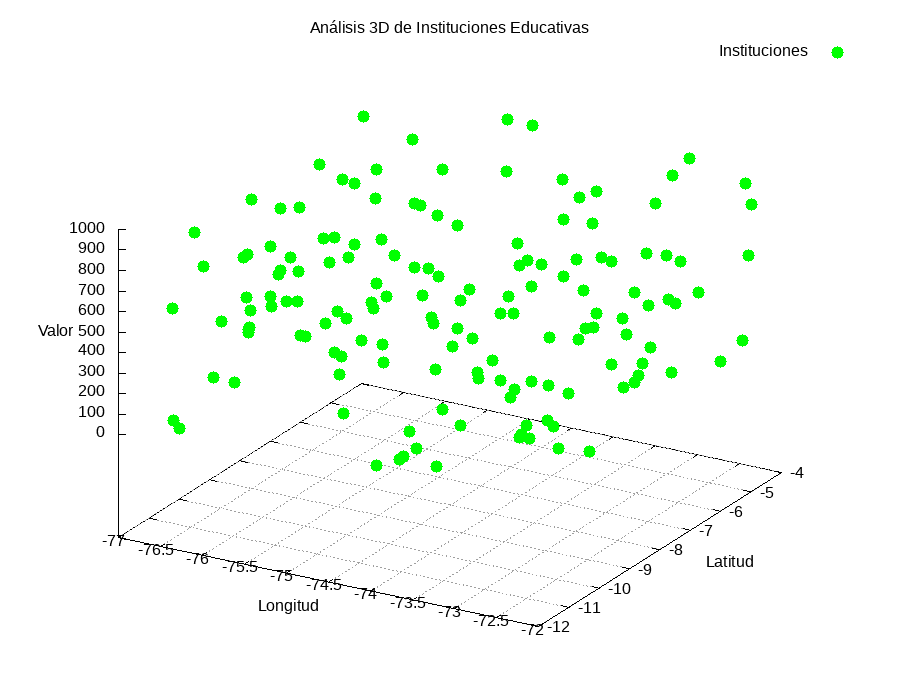

In [9]:
display(Image('plots/grafico3.png'))